result
1    865
0    135
Name: count, dtype: int64
Training data: (800, 6)
Testing data: (200, 6)
   Actual  Predicted
0       1          1
1       1          1
2       1          1
3       1          1
4       1          1
5       1          1
6       1          1
7       1          1
8       1          1
9       1          0

Correct predictions: 178
Wrong predictions:   22

Accuracy: 0.89


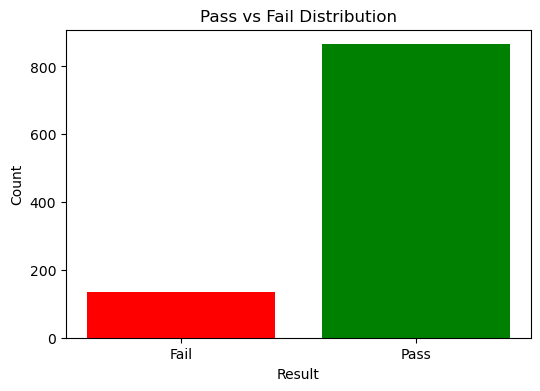

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv("StudentsPerformance.csv")

# Label Encoding
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
df["race/ethnicity"] = le.fit_transform(df["race/ethnicity"])
df["lunch"] = le.fit_transform(df["lunch"])
df["test preparation course"] = le.fit_transform(df["test preparation course"])

# Create result column
df["result"] = (df["math score"] >= 50).astype(int)

print(df["result"].value_counts())

# Select X and y
X = df[["reading score", "writing score", "lunch", 
        "test preparation course", "gender", "race/ethnicity"]]
y = df["result"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Compare results
results = pd.DataFrame({
    "Actual":    y_test.values,
    "Predicted": predictions
})
print(results.head(10))
print(f"\nCorrect predictions: {(results['Actual'] == results['Predicted']).sum()}")
print(f"Wrong predictions:   {(results['Actual'] != results['Predicted']).sum()}")

# Evaluate
accuracy = accuracy_score(y_test, predictions)
print(f"\nAccuracy: {accuracy:.2f}")

# Visualize
plt.figure(figsize=(6, 4))
labels = ["Fail", "Pass"]
counts = [len(df[df["result"] == 0]), len(df[df["result"] == 1])]
plt.bar(labels, counts, color=["red", "green"])
plt.title("Pass vs Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()